In [3]:
import pandas as pd

f1 = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file_with_s5p_90360.csv"
f2 = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/_plume_to_s5p_match.csv"
out = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file_with_s5p_90360_plus_match.csv"

df1 = pd.read_csv(f1, low_memory=False)
df2 = pd.read_csv(f2, low_memory=False)

# 统一列名
df1 = df1.rename(columns={
    "datetime": "plume_time",
    "plume_latitude": "lat",
    "plume_longitude": "lon",
})

df1_keep = df1[[
    "plume_id", "plume_time", "lat", "lon",
    "s5p_minus360_path", "s5p_minus90_path"
]].copy()

# ---- 关键：只要 matched=True 的 S5P(t0) 结果 ----
df2 = df2[df2["matched"] == True].copy()

# 如果同一个 plume_id 在 f2 里可能出现多条（保险起见），取 dist_km 最小的那条
if "dist_km" in df2.columns:
    df2["dist_km"] = pd.to_numeric(df2["dist_km"], errors="coerce")
    df2 = df2.sort_values(["plume_id", "dist_km"], ascending=[True, True])

df2_keep = df2[["plume_id", "file"]].drop_duplicates("plume_id", keep="first").copy()
df2_keep = df2_keep.rename(columns={"file": "S5p_path"})

merged = df1_keep.merge(df2_keep, on="plume_id", how="inner")

# 三个路径都要非空
def ok(x):
    return pd.notna(x) and str(x).strip() != ""

mask = (
    merged["s5p_minus360_path"].apply(ok) &
    merged["s5p_minus90_path"].apply(ok) &
    merged["S5p_path"].apply(ok)
)

merged = merged.loc[mask, [
    "plume_id", "plume_time", "lat", "lon",
    "s5p_minus360_path", "s5p_minus90_path", "S5p_path"
]].reset_index(drop=True)

merged.to_csv(out, index=False)
print("Saved:", out)
print("Rows:", len(merged))


Saved: /data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file_with_s5p_90360_plus_match.csv
Rows: 7445


In [1]:
import pandas as pd
import re

in_csv = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file_with_s5p_90360_plus_match.csv"
out_offl = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_OFFL.csv"
out_rpro = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_RPRO.csv"

df = pd.read_csv(in_csv, low_memory=False)

# 从 S5P 文件名里提取 OFFL / RPRO / NRTI
def get_proc(path):
    if not isinstance(path, str):
        return None
    m = re.search(r"S5P_(OFFL|RPRO|NRTI)", path)
    if m:
        return m.group(1)
    return None

df["proc_0"]    = df["S5p_path"].apply(get_proc)
df["proc_90"]   = df["s5p_minus90_path"].apply(get_proc)
df["proc_360"]  = df["s5p_minus360_path"].apply(get_proc)

# 只保留三者都能识别出 proc 的
df = df.dropna(subset=["proc_0", "proc_90", "proc_360"])

# 三个都是 OFFL
all_offl = df[(df["proc_0"]=="OFFL") & (df["proc_90"]=="OFFL") & (df["proc_360"]=="OFFL")]

# 三个都是 RPRO
all_rpro = df[(df["proc_0"]=="RPRO") & (df["proc_90"]=="RPRO") & (df["proc_360"]=="RPRO")]

# === 找出 mixed 的行 ===
mixed = df[
    ~(
        ((df["proc_0"]=="OFFL") & (df["proc_90"]=="OFFL") & (df["proc_360"]=="OFFL")) |
        ((df["proc_0"]=="RPRO") & (df["proc_90"]=="RPRO") & (df["proc_360"]=="RPRO"))
    )
]

if len(mixed) > 0:
    row = mixed.iloc[0]
    print("\nExample mixed case:")
    print("proc_0  :", row["proc_0"],  row["S5p_path"])
    print("proc_90 :", row["proc_90"], row["s5p_minus90_path"])
    print("proc_360:", row["proc_360"], row["s5p_minus360_path"])
else:
    print("\nNo mixed cases found.")
    
print("Total rows:", len(df))
print("All OFFL:", len(all_offl))
print("All RPRO:", len(all_rpro))
print("Mixed (OFFL/RPRO/NRTI):", len(df) - len(all_offl) - len(all_rpro))

# # 导出
# all_offl.to_csv(out_offl, index=False)
# all_rpro.to_csv(out_rpro, index=False)

# print("Saved:", out_offl)
# print("Saved:", out_rpro)



Example mixed case:
proc_0  : OFFL /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20191019T192023_20191019T210153_10448_01_010302_20191025T213811.nc
proc_90 : OFFL /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p_90360/S5P_OFFL_L2__CH4____20190720T193504_20190720T211634_09157_01_010302_20190726T213837.nc
proc_360: RPRO /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p_90360/S5P_RPRO_L2__CH4____20181023T184844_20181023T203014_05326_03_020400_20221115T110625.nc
Total rows: 7445
All OFFL: 4512
All RPRO: 771
Mixed (OFFL/RPRO/NRTI): 2162


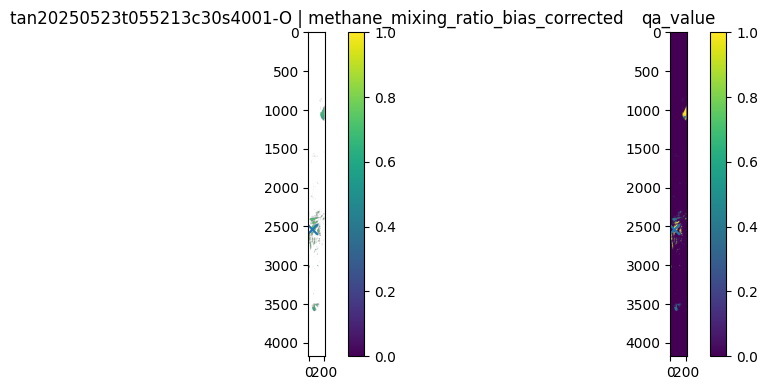

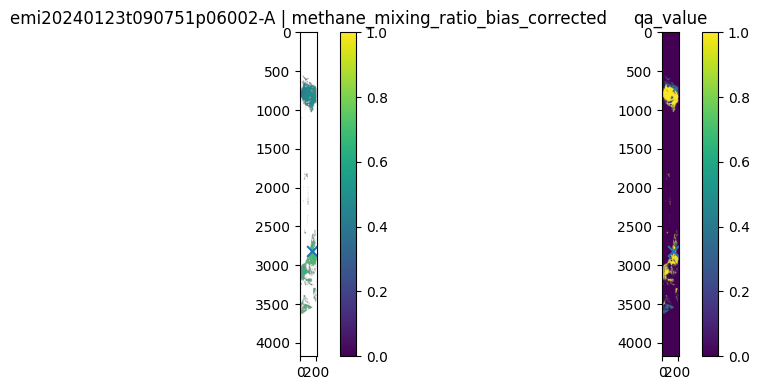

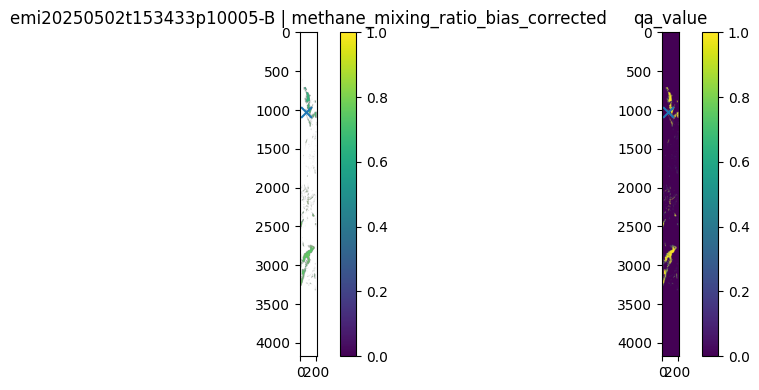

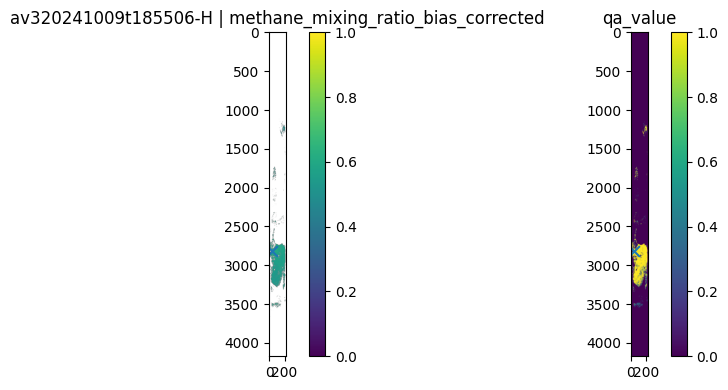

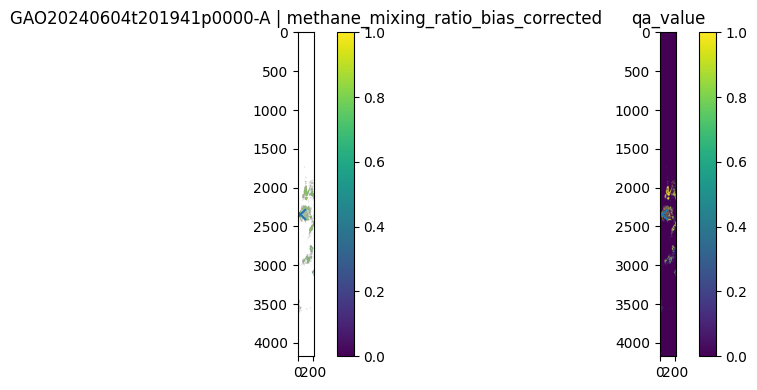

In [5]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

csv_path = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_OFFL.csv"  # 你刚导出的 all OFFL 表
K = 5  # 看几张

df = pd.read_csv(csv_path, low_memory=False)
sample = df.sample(K, random_state=0)

def pick_ch4_var(ds):
    for k in ["methane_mixing_ratio_bias_corrected", "methane_mixing_ratio", "xch4"]:
        if k in ds.variables:
            return k
    return None

def nearest_pixel_iyix(lat_arr, lon_arr, lat0, lon0):
    # 使用近似球面距离（与之前一致）
    lat_rad = np.deg2rad(lat_arr)
    lon_rad = np.deg2rad(lon_arr)
    lat0r = np.deg2rad(lat0)
    lon0r = np.deg2rad(lon0)
    dlon = (lon_rad - lon0r + np.pi) % (2*np.pi) - np.pi
    x = dlon * np.cos(0.5 * (lat_rad + lat0r))
    y = (lat_rad - lat0r)
    dist2 = x*x + y*y
    flat = np.nanargmin(dist2)
    unr = np.unravel_index(flat, dist2.shape)
    if len(unr) == 3:
        it, iy, ix = unr
    else:
        it, iy, ix = 0, unr[0], unr[1]
    return it, iy, ix

for _, r in sample.iterrows():
    lat0, lon0 = float(r["lat"]), float(r["lon"])
    s5p_path = r["S5p_path"]

    ds = xr.open_dataset(s5p_path, group="PRODUCT", engine="netcdf4", decode_timedelta=True)
    lat = ds["latitude"].values
    lon = ds["longitude"].values
    qa = ds["qa_value"].values if "qa_value" in ds.variables else None
    ch4_name = pick_ch4_var(ds)
    ch4 = ds[ch4_name].values if ch4_name else None

    it, iy, ix = nearest_pixel_iyix(lat, lon, lat0, lon0)

    fig = plt.figure(figsize=(10,4))
    if ch4 is not None:
        plt.subplot(1,2,1)
        img = ch4[it] if ch4.ndim==3 else ch4
        plt.imshow(img)
        plt.scatter([ix],[iy], s=60, marker="x")
        plt.title(f"{r['plume_id']} | {ch4_name}")
        plt.colorbar(fraction=0.046, pad=0.04)

    if qa is not None:
        plt.subplot(1,2,2)
        img = qa[it] if qa.ndim==3 else qa
        plt.imshow(img)
        plt.scatter([ix],[iy], s=60, marker="x")
        plt.title("qa_value")
        plt.colorbar(fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    ds.close()


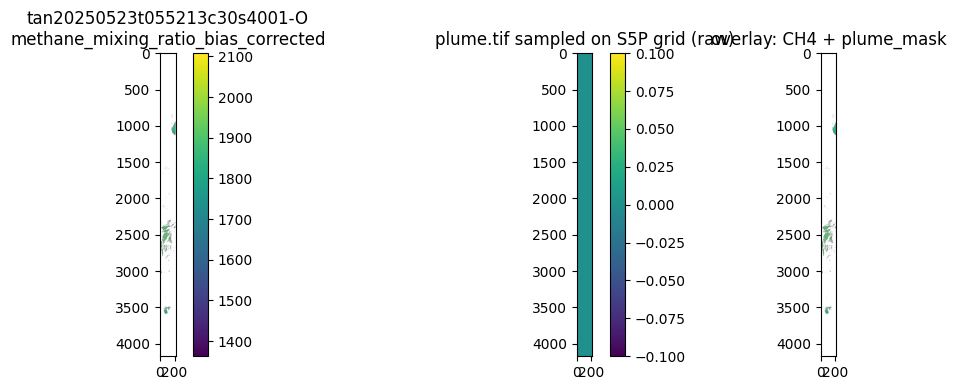

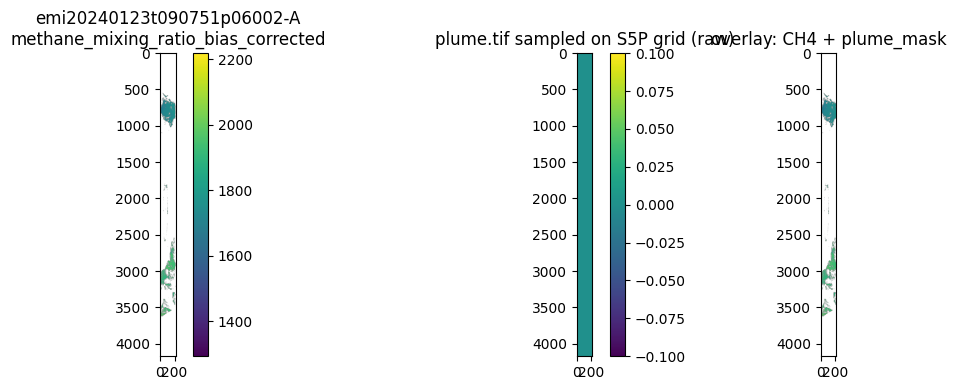

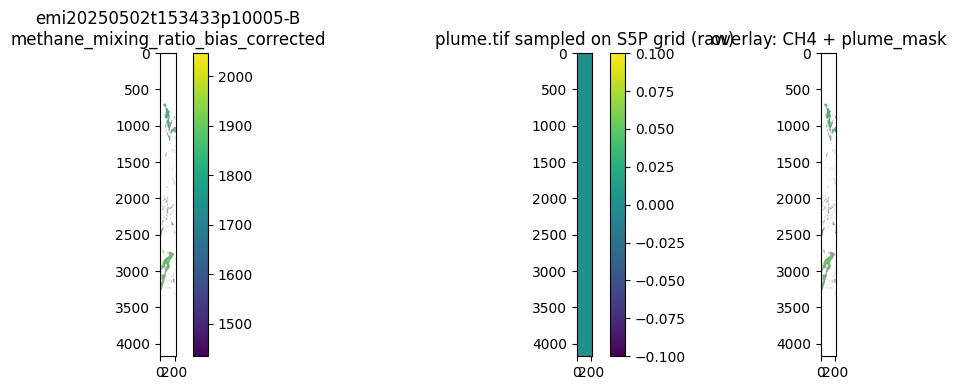

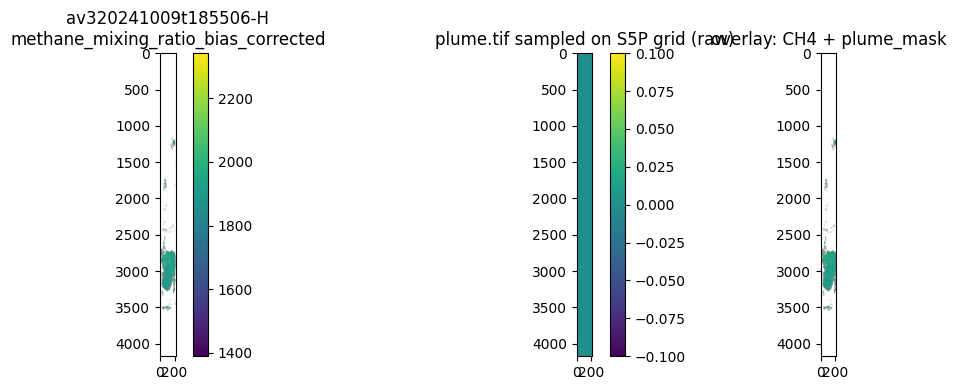

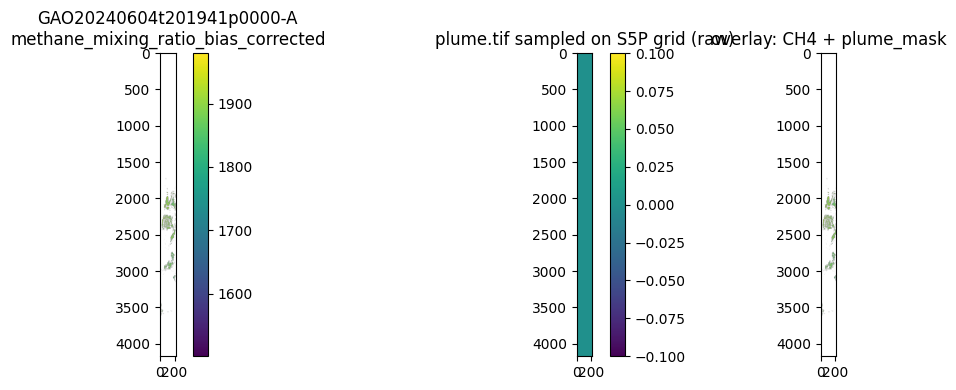

In [9]:
import pandas as pd
import numpy as np
import xarray as xr
import rasterio
from pyproj import Transformer
import matplotlib.pyplot as plt
from pathlib import Path

# 直接用原来的 OFFL.csv
csv_path = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_OFFL.csv"

# 你的本地 plume mask 根目录（按你截图的结构：.../carbon_mapper_data_masks/<plume_id>/plume.tif）
MASK_ROOT = Path("/data2/yuyao/methane_emission/carbon_mapper_data_masks")

K = 5
rng = 0

df_all = pd.read_csv(csv_path, low_memory=False)

# 只抽“本地 plume.tif 存在”的样本，避免抽到缺文件
def plume_path_from_id(plume_id: str) -> Path:
    return MASK_ROOT / str(plume_id) / "plume.tif"

exists_mask = df_all["plume_id"].astype(str).apply(lambda pid: plume_path_from_id(pid).exists())
df = df_all[exists_mask].sample(K, random_state=rng)

def pick_ch4_var(ds):
    for k in ["methane_mixing_ratio_bias_corrected", "methane_mixing_ratio", "xch4"]:
        if k in ds.variables:
            return k
    return None

def plume_to_s5p_mask(plume_tif_path, s5p_lat, s5p_lon):
    """
    plume_tif_path: 本地 plume.tif (GeoTIFF)
    s5p_lat/lon: shape=(T,H,W) 或 (H,W)
    return: plume_on_s5p (H,W) float, plume_mask (H,W) bool
    """
    # 统一成 (H,W)
    if s5p_lat.ndim == 3:
        lat2 = s5p_lat[0]
        lon2 = s5p_lon[0]
    else:
        lat2, lon2 = s5p_lat, s5p_lon

    with rasterio.open(plume_tif_path) as src:
        plume_crs = src.crs
        nodata = src.nodata

        if plume_crs is None:
            raise RuntimeError(f"plume tif 没有 CRS 信息：{plume_tif_path}")

        # S5P lat/lon 是 EPSG:4326
        if str(plume_crs).lower() in ["epsg:4326", "crs:84"]:
            xs, ys = lon2, lat2
        else:
            tfm = Transformer.from_crs("EPSG:4326", plume_crs, always_xy=True)
            xs, ys = tfm.transform(lon2.astype(float), lat2.astype(float))

        pts = np.column_stack([xs.ravel(), ys.ravel()])
        vals = np.array([v[0] for v in src.sample(pts)], dtype=np.float32)
        plume_on_s5p = vals.reshape(lat2.shape)

        if nodata is not None:
            plume_on_s5p = np.where(plume_on_s5p == nodata, np.nan, plume_on_s5p)

    plume_mask = np.isfinite(plume_on_s5p) & (plume_on_s5p != 0)
    return plume_on_s5p, plume_mask

for _, r in df.iterrows():
    plume_id = r["plume_id"]
    plume_tif = plume_path_from_id(r["plume_id"])   # ✅ 用本地路径
    s5p_path = r["S5p_path"]

    # 打开 S5P（PRODUCT group）
    ds = xr.open_dataset(s5p_path, group="PRODUCT", engine="netcdf4", decode_timedelta=True)
    lat = ds["latitude"].values
    lon = ds["longitude"].values

    qa = ds["qa_value"].values if "qa_value" in ds.variables else None
    ch4_name = pick_ch4_var(ds)
    ch4 = ds[ch4_name].values if ch4_name else None

    # plume 投影到 S5P 网格
    plume_on_s5p, plume_mask = plume_to_s5p_mask(str(plume_tif), lat, lon)

    # 可视化：左 ch4；中 plume_on_s5p（raw）；右 overlay
    fig = plt.figure(figsize=(13, 4))

    plt.subplot(1, 3, 1)
    if ch4 is not None:
        img = ch4[0] if ch4.ndim == 3 else ch4
        plt.imshow(img)
        plt.title(f"{plume_id}\n{ch4_name}")
        plt.colorbar(fraction=0.046, pad=0.04)
    else:
        plt.imshow(plume_mask.astype(np.uint8))
        plt.title(f"{plume_id}\n(no CH4 var found)")

    plt.subplot(1, 3, 2)
    plt.imshow(plume_on_s5p)
    plt.title("plume.tif sampled on S5P grid (raw)")
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 3)
    if ch4 is not None:
        base = ch4[0] if ch4.ndim == 3 else ch4
        plt.imshow(base)
        ys, xs = np.where(plume_mask)
        plt.scatter(xs, ys, s=6)
        plt.title("overlay: CH4 + plume_mask")
    else:
        plt.imshow(plume_mask.astype(np.uint8))
        plt.title("plume_mask (0/1)")

    plt.tight_layout()
    plt.show()

    ds.close()


In [9]:
# 2 划分训练集和测试集
import pandas as pd
all_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/s5p_patches_3x3_to_32.csv'
df = pd.read_csv(all_csv)
df['date'] = pd.to_datetime(df['plume_time'])
train_df = df[(df['date'] < '2024-10-10')]  # 2025-04-01
test_df = df[(df['date'] >= '2024-10-10') & (df['date'] < '2024-12-01')]
            #  & (df['date'] < '2024-06-01')]
print(f'training set {len(train_df)} testing set {len(test_df)} train percentage {len(train_df)/(len(train_df)+len(test_df)):.3f}')

# /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl_2024/train.csv
train_csv = '/data2/yuyao/methane_emission/data_csv/s5p_patches_3x3_to_32_offl_2024/train.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/data2/yuyao/methane_emission/data_csv/s5p_patches_3x3_to_32_offl_2024/test.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')

training set 1505 testing set 172 train percentage 0.897
train set size 1505
test set size 172


In [ ]:
# find center positions and labeling 
import pandas as pd
from pathlib import Path

# ===== input =====
TRAIN_IN = "/data2/yuyao/methane_emission/data_csv/s5p_patches_3x3_to_32_offl_2024/train.csv"
TEST_IN  = "/data2/yuyao/methane_emission/data_csv/s5p_patches_3x3_to_32_offl_2024/test.csv"

OUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl")
TRAIN_OUT = OUT_DIR / "2024_train.csv"
TEST_OUT  = OUT_DIR / "2024_test.csv"


KEEP_BASE = [
    "plume_id",
    "plume_time",
    "lat",
    "lon",
    "has_90",
    "has_360",
    "ch4_var",
]

CENTER_COLS = [
    "pos_center_iy",
    "pos_center_ix",
    "neg_center_iy",
    "neg_center_ix",
]


def explode_csv(path_in, path_out):
    df = pd.read_csv(path_in)

    rows = []

    for _, r in df.iterrows():
        base = {k: r[k] for k in KEEP_BASE}

        # ---------- positive ----------
        rows.append({
            **base,
            "image_path": r["pos_npz_path"],
            "center_iy": r["pos_center_iy"],
            "center_ix": r["pos_center_ix"],
            "label": 1,
        })

        # ---------- negative ----------
        rows.append({
            **base,
            "image_path": r["neg_npz_path"],
            "center_iy": r["neg_center_iy"],
            "center_ix": r["neg_center_ix"],
            "label": 0,
        })

    out = pd.DataFrame(rows)

    # keep strict column order
    out = out[
        [
            "plume_id",
            "plume_time",
            "lat",
            "lon",
            "has_90",
            "has_360",
            "ch4_var",
            "image_path",
            "center_iy",
            "center_ix",
            "label",
        ]
    ]

    out.to_csv(path_out, index=False)
    print("Saved:", path_out, "rows:", len(out))


explode_csv(TRAIN_IN, TRAIN_OUT)
explode_csv(TEST_IN, TEST_OUT)

Saved: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/2024_train.csv rows: 3010
Saved: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/2024_test.csv rows: 344


In [12]:
import pandas as pd
train_csv_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/2024_train.csv'
test_csv_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/2024_test.csv'
train_df = pd.read_csv(train_csv_path)
train_plume_df = train_df[train_df['label'] == 1]
print(f'train set size {len(train_plume_df)}/{len(train_df)}')

test_df = pd.read_csv(test_csv_path)
test_plume_df = test_df[test_df['label'] == 1]
print(f'test set size {len(test_plume_df)}/{len(test_df)}')

train set size 1505/3010
test set size 172/344


In [2]:
import os
import math
import warnings
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
from netCDF4 import Dataset


# IN_CSV  = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_OFFL.csv"
# OUT_CSV = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_OFFL_with_centers.csv"

IN_CSV = "/data2/yuyao/methane_emission/preprocess_dataset_s5p/redownload_offl_90360_manifest_with_paths.csv"
OUT_CSV = "/data2/yuyao/methane_emission/preprocess_dataset_s5p/redownload_offl_90360_manifest_with_centers.csv"

CROP_SIZE = 5
CROP_HALF = CROP_SIZE // 2  # 2
MAX_MISSING_RATIO_T0 = 0.50
MAX_POS_PER_PLUME = 8

CH4_CANDIDATES = [
    "methane_mixing_ratio_bias_corrected",
    "methane_mixing_ratio",
    "xch4",
]

warnings.filterwarnings("ignore", category=RuntimeWarning)

@contextmanager
def silence_fd2():
    """Kill HDF5/getfattr spam that bypasses Python warnings."""
    devnull = os.open(os.devnull, os.O_WRONLY)
    old = os.dup(2)
    try:
        os.dup2(devnull, 2)
        yield
    finally:
        os.dup2(old, 2)
        os.close(devnull)
        os.close(old)


def get_2d(a):
    a = np.asarray(a)
    if a.ndim == 3:
        return a[0]
    if a.ndim == 2:
        return a
    raise ValueError(f"Unexpected dims: {a.shape}")


def to_nan_invalid(arr, attrs=None):
    a = np.array(arr, dtype=np.float32, copy=False)
    attrs = attrs or {}
    fv = attrs.get("_FillValue", None)
    mv = attrs.get("missing_value", None)
    if fv is not None:
        a = np.where(a == np.float32(fv), np.nan, a)
    if mv is not None:
        a = np.where(a == np.float32(mv), np.nan, a)
    a = np.where(np.abs(a) > 1e20, np.nan, a)
    return get_2d(a)


def missing_ratio(patch2d):
    return 1.0 - (np.isfinite(patch2d).sum() / patch2d.size)


def crop_center(a2d, cy, cx, half):
    H, W = a2d.shape
    y0, y1 = cy - half, cy + half + 1
    x0, x1 = cx - half, cx + half + 1
    if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
        return None
    return a2d[y0:y1, x0:x1]


def pick_ch4_var(prod):
    for k in CH4_CANDIDATES:
        if k in prod.variables:
            return k
    return None


def nearest_iyix(lat, lon, lat0, lon0):
    lat = lat.astype(np.float64, copy=False)
    lon = lon.astype(np.float64, copy=False)
    latr = np.deg2rad(lat)
    lonr = np.deg2rad(lon)
    lat0r = math.radians(float(lat0))
    lon0r = math.radians(float(lon0))

    dlon = (lonr - lon0r + np.pi) % (2*np.pi) - np.pi
    x = dlon * np.cos(0.5 * (latr + lat0r))
    y = latr - lat0r
    d2 = x*x + y*y

    flat = np.nanargmin(d2)
    iy, ix = np.unravel_index(flat, d2.shape)
    return int(iy), int(ix)


def candidate_pos_centers(py, px, H, W):
    centers = []
    y_min, y_max = CROP_HALF, H - CROP_HALF - 1
    x_min, x_max = CROP_HALF, W - CROP_HALF - 1
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            cy = py + dy
            cx = px + dx
            if y_min <= cy <= y_max and x_min <= cx <= x_max:
                centers.append((cy, cx))
    centers.sort(key=lambda c: (c[0]-py)**2 + (c[1]-px)**2)
    return centers


def encode_centers(centers):
    # "cy,cx;cy,cx;..."
    return ";".join([f"{cy},{cx}" for cy, cx in centers])


def main():
    df = pd.read_csv(IN_CSV, low_memory=False)
    req = ["plume_id","plume_time","lat","lon","S5p_path","s5p_minus90_path","s5p_minus360_path"]
    for c in req:
        if c not in df.columns:
            raise RuntimeError(f"Missing col {c}")

    nearest_iy = []
    nearest_ix = []
    pos_centers_str = []
    ch4_varname = []
    ok = 0
    bad = 0

    for i, r in df.iterrows():
        try:
            p0 = str(r["S5p_path"])
            lat0 = float(r["lat"])
            lon0 = float(r["lon"])

            with silence_fd2():
                ds = Dataset(p0, "r")
            prod = ds.groups["PRODUCT"]

            lat = get_2d(prod.variables["latitude"][:])
            lon = get_2d(prod.variables["longitude"][:])

            ch4name = pick_ch4_var(prod)
            if ch4name is None:
                ds.close()
                raise RuntimeError("no_ch4")

            ch4v = prod.variables[ch4name]
            ch40 = to_nan_invalid(ch4v[:], getattr(ch4v, "__dict__", {}))

            ds.close()

            py, px = nearest_iyix(lat, lon, lat0, lon0)

            H, W = ch40.shape
            cands = candidate_pos_centers(py, px, H, W)

            kept = []
            for cy, cx in cands:
                p = crop_center(ch40, cy, cx, CROP_HALF)
                if p is None:
                    continue
                if missing_ratio(p) <= MAX_MISSING_RATIO_T0:
                    kept.append((cy, cx))
                if len(kept) >= MAX_POS_PER_PLUME:
                    break

            nearest_iy.append(py)
            nearest_ix.append(px)
            pos_centers_str.append(encode_centers(kept))
            ch4_varname.append(ch4name)

            ok += 1
        except Exception:
            nearest_iy.append(np.nan)
            nearest_ix.append(np.nan)
            pos_centers_str.append("")
            ch4_varname.append("")
            bad += 1

        if (i+1) % 200 == 0:
            print(f"[{i+1}/{len(df)}] ok={ok} bad={bad}")

    df["nearest_iy"] = nearest_iy
    df["nearest_ix"] = nearest_ix
    df["pos_centers"] = pos_centers_str
    df["ch4_var"] = ch4_varname

    df.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV, "ok=", ok, "bad=", bad)


if __name__ == "__main__":
    main()


[200/1675] ok=200 bad=0
[400/1675] ok=400 bad=0
[600/1675] ok=600 bad=0
[800/1675] ok=800 bad=0
[1000/1675] ok=1000 bad=0
[1200/1675] ok=1200 bad=0
[1400/1675] ok=1400 bad=0
[1600/1675] ok=1600 bad=0
Saved: /data2/yuyao/methane_emission/preprocess_dataset_s5p/redownload_offl_90360_manifest_with_centers.csv ok= 1675 bad= 0


In [13]:
# 3 划分训练集和测试集
import pandas as pd
all_csv = './s5p_samples_5x5_to_32_triplet.csv'
df = pd.read_csv(all_csv)
df['date'] = pd.to_datetime(df['plume_time'])
# train_df = df[(df['date'] < '2024-10-10') | (df['date'] >= '2025-10-01')]  # 2025-04-01
# test_df = df[(df['date'] >= '2024-10-10') & (df['date'] < '2025-01-01')]
train_df = df[(df['date'] < '2024-10-10')]  # 2025-04-01
test_df = df[(df['date'] >= '2024-10-10') & (df['date'] < '2025-01-01')]
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')

train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_5x5_to_32_offl_triplet/samples2/train_2024.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_5x5_to_32_offl_triplet/samples2/test_2024.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')


training set 28410 testing set 4940 train ratio 0.852
train set size 28410
test set size 4940



=== S2 yearly centroids ===
 year  plume_latitude  plume_longitude
 2016       35.644506      -119.278814
 2017       34.973710      -119.016537
 2018       35.175867      -118.947829
 2019       31.994474      -103.099747
 2020       34.763147      -110.172423
 2021       33.666326      -102.018377
 2022       37.750089       -73.176776
 2023       32.877976       -60.862556
 2024       30.545843       -60.667344
 2025       32.825189        -2.168402

=== S5P yearly centroids ===
 year       lat         lon
 2020 35.773350 -118.327138
 2023 33.896875  -26.752477
 2024 31.657336  -72.013811
 2025 30.156208   -0.851757

=== Period comparison ===
S2  Period A centroid:  lat=33.5716, lon=-90.2602
S2  Period B centroid:  lat=32.2339, lon=-11.3564
S2  Centroid shift (km): 7171.6

S5P Period A centroid:  lat=32.7142, lon=-74.1552
S5P Period B centroid:  lat=30.5399, lon=-20.7202
S5P Centroid shift (km): 5010.8


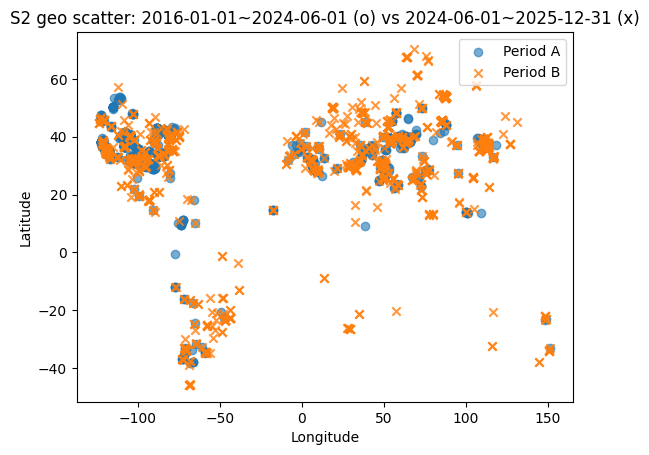

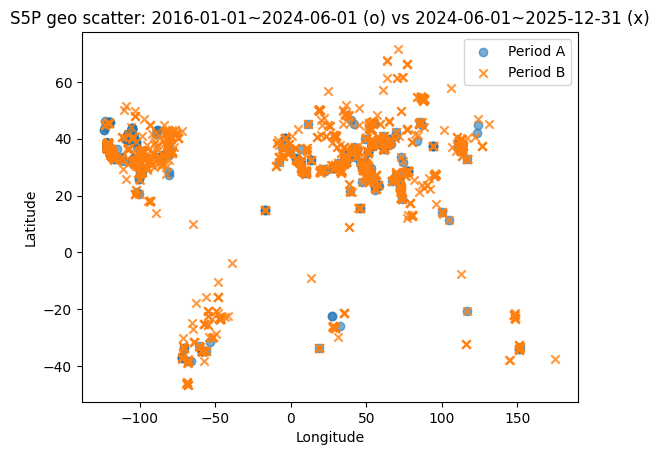

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos, asin, sqrt

# =========================
# 0) 你只需要改这里
# =========================
S2_CSV  = "/data2/yuyao/methane_emission/preprocess_dataset_s2/raw_s2_90360_cleaned_fixed.csv"
S5P_CSV = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/s5p_all_OFFL.csv"

# 你要对比的两个时间段（可随便改）
# 例子：把 2016-2024 vs 2025 做对比
A_START, A_END = "2016-01-01", "2024-06-01"
B_START, B_END = "2024-06-01", "2025-12-31"

# 如果你想按“年份”看质心，就用这个：
YEAR_MIN, YEAR_MAX = 2016, 2025

# =========================
# 1) 工具函数
# =========================
def haversine_km(lat1, lon1, lat2, lon2):
    """两点球面距离 (km)"""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

def geo_centroid(df, lat_col, lon_col):
    """地理中心 (mean lat/lon)"""
    return df[[lat_col, lon_col]].mean()

def filter_time(df, time_col, start, end):
    """按时间过滤，start/end 都包含；自动统一成 UTC-aware 后再比较"""
    t = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts   = pd.Timestamp(end, tz="UTC")
    m = (t >= start_ts) & (t <= end_ts)
    return df[m].copy()

def yearly_centroids(df, time_col, lat_col, lon_col, year_min=None, year_max=None):
    """按年计算质心（时间统一成 UTC）"""
    t = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.copy()
    df["year"] = t.dt.year

    out = df.groupby("year")[[lat_col, lon_col]].mean().reset_index()
    if year_min is not None:
        out = out[out["year"] >= year_min]
    if year_max is not None:
        out = out[out["year"] <= year_max]
    return out

def scatter_compare(dfA, dfB, lat_col, lon_col, title):
    """画两段时间散点对比"""
    plt.figure()
    plt.scatter(dfA[lon_col], dfA[lat_col], marker="o", alpha=0.6, label="Period A")
    plt.scatter(dfB[lon_col], dfB[lat_col], marker="x", alpha=0.8, label="Period B")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.legend()
    plt.show()

# =========================
# 2) 读数据 + 设定列名
# =========================
s2 = pd.read_csv(S2_CSV)
s5p = pd.read_csv(S5P_CSV)

# S2 的列名（按你文件）
S2_TIME = "datetime"
S2_LAT  = "plume_latitude"
S2_LON  = "plume_longitude"

# S5P 的列名（按你文件）
S5P_TIME = "plume_time"
S5P_LAT  = "lat"
S5P_LON  = "lon"

# =========================
# 3) 计算按年质心（可用于快速看漂移）
# =========================
s2_year = yearly_centroids(s2, S2_TIME, S2_LAT, S2_LON, YEAR_MIN, YEAR_MAX)
s5p_year = yearly_centroids(s5p, S5P_TIME, S5P_LAT, S5P_LON, YEAR_MIN, YEAR_MAX)

print("\n=== S2 yearly centroids ===")
print(s2_year.to_string(index=False))

print("\n=== S5P yearly centroids ===")
print(s5p_year.to_string(index=False))

# =========================
# 4) 对比两段时间的质心 + 漂移距离（km）
# =========================
s2_A = filter_time(s2, S2_TIME, A_START, A_END)
s2_B = filter_time(s2, S2_TIME, B_START, B_END)

s5p_A = filter_time(s5p, S5P_TIME, A_START, A_END)
s5p_B = filter_time(s5p, S5P_TIME, B_START, B_END)

s2_cA = geo_centroid(s2_A, S2_LAT, S2_LON)
s2_cB = geo_centroid(s2_B, S2_LAT, S2_LON)
s2_shift = haversine_km(s2_cA[S2_LAT], s2_cA[S2_LON], s2_cB[S2_LAT], s2_cB[S2_LON])

s5p_cA = geo_centroid(s5p_A, S5P_LAT, S5P_LON)
s5p_cB = geo_centroid(s5p_B, S5P_LAT, s5p_B[S5P_LON].name)
# ↑ 这行写得有点怪，为了清晰我直接改成下面这一行（同样效果）
s5p_cB = geo_centroid(s5p_B, S5P_LAT, S5P_LON)

s5p_shift = haversine_km(s5p_cA[S5P_LAT], s5p_cA[S5P_LON], s5p_cB[S5P_LAT], s5p_cB[S5P_LON])

print("\n=== Period comparison ===")
print(f"S2  Period A centroid:  lat={s2_cA[S2_LAT]:.4f}, lon={s2_cA[S2_LON]:.4f}")
print(f"S2  Period B centroid:  lat={s2_cB[S2_LAT]:.4f}, lon={s2_cB[S2_LON]:.4f}")
print(f"S2  Centroid shift (km): {s2_shift:.1f}")

print(f"\nS5P Period A centroid:  lat={s5p_cA[S5P_LAT]:.4f}, lon={s5p_cA[S5P_LON]:.4f}")
print(f"S5P Period B centroid:  lat={s5p_cB[S5P_LAT]:.4f}, lon={s5p_cB[S5P_LON]:.4f}")
print(f"S5P Centroid shift (km): {s5p_shift:.1f}")

# =========================
# 5) 画图：两段时间散点对比
# =========================
scatter_compare(
    s2_A, s2_B, S2_LAT, S2_LON,
    title=f"S2 geo scatter: {A_START}~{A_END} (o) vs {B_START}~{B_END} (x)"
)

scatter_compare(
    s5p_A, s5p_B, S5P_LAT, S5P_LON,
    title=f"S5P geo scatter: {A_START}~{A_END} (o) vs {B_START}~{B_END} (x)"
)
